In [1]:
from datetime import datetime
from portfolio_optimization import *

# U.S. Industry ETFs
us_industry_etfs = {
    "XLF": "Financials",                # Financial Select Sector SPDR Fund
    "XLK": "Technology",                # Technology Select Sector SPDR Fund
    "XLE": "Energy",                    # Energy Select Sector SPDR Fund
    "XLI": "Industrials",               # Industrial Select Sector SPDR Fund
    "XLU": "Utilities",                 # Utilities Select Sector SPDR Fund
    "XLP": "Consumer Staples",          # Consumer Staples Select Sector SPDR Fund
    "XLY": "Consumer Discretionary",    # Consumer Discretionary Select Sector SPDR Fund
    "XLV": "Health Care",               # Health Care Select Sector SPDR Fund
    "XLB": "Materials",                 # Materials Select Sector SPDR Fund
    "XLRE": "Real Estate"               # Real Estate Select Sector SPDR Fund
}

trading_days_in_year = 252
# Define the start and end dates for fetching the data
start_date = '1990-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

In [2]:
!pip install pandas yfinance matplotlib seaborn

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

returns_df = pd.DataFrame()

# Fetch daily returns for each ticker
for ticker, asset_class in us_industry_etfs.items():
    try:
        # Fetch historical data for the ticker
        data = yf.download(ticker)
        
        # Check if the data is empty
        if data.empty:
            print(f"No data found for ticker: {ticker}")
            continue
        
        # Calculate daily returns
        data['Daily Return'] = data['Adj Close'].pct_change()
        
        # Add the daily returns to the returns DataFrame
        data = data[['Daily Return']].rename(columns={'Daily Return': asset_class})
        if returns_df.empty:
            returns_df = data
        else:
            returns_df = returns_df.join(data, how='outer')
    except Exception as e:
        print(f"Failed for ticker: {ticker}")
        print(e)
        
# Drop the first row with NaN values
returns_df = returns_df.iloc[1:]
returns_df.to_csv("../data/historical-class-returns.csv")
# Display the first few rows of the returns DataFrame

# VERY IMPORTANT, OTHERWISE MANY COMPUTATIONS WOULD RETURN NONE, FROM 
# PORT OPT, to RISK CONT!
returns_df.fillna(0, inplace=True)
returns_df.head()

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


,Financials,Technology,Energy,Industrials,Utilities,Consumer Staples,Consumer Discretionary,Health Care,Materials,Real Estate
Date,,,,,,,,,,
1998-12-23,0.014745,0.023891,0.020820,0.017449,-0.004190,0.024175,0.004294,0.022471,0.010503,0.0
1998-12-24,0.006605,-0.003809,-0.005264,0.013193,0.018411,-0.001727,0.018326,0.006105,0.023014,0.0
1998-12-28,-0.013124,0.002868,-0.005291,0.005208,-0.005165,-0.005767,-0.008998,-0.014563,-0.008708,0.0
1998-12-29,0.010639,0.002860,0.009974,0.014249,0.016615,0.022041,0.021792,0.022167,0.018302,0.0
1998-12-30,-0.003947,-0.003803,-0.015142,-0.004470,-0.008171,-0.006242,-0.008294,-0.008434,-0.002876,0.0


Previous example, notice how despite even weight allocation, risk contribution is diff per asset

/tmp/ipykernel_21571/1737874088.py:217: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  stored_weights_filled = stored_weights_shifted.ffill().fillna(0)
/home/alan/Quantropy/env/lib/python3.10/site-packages/pandas/core/frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/home/alan/Quantropy/env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/alan/Quantropy/env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/tmp/ipykernel_21571/1737874088.py:87: RuntimeWarning: invalid value encountered in divide
  return marg

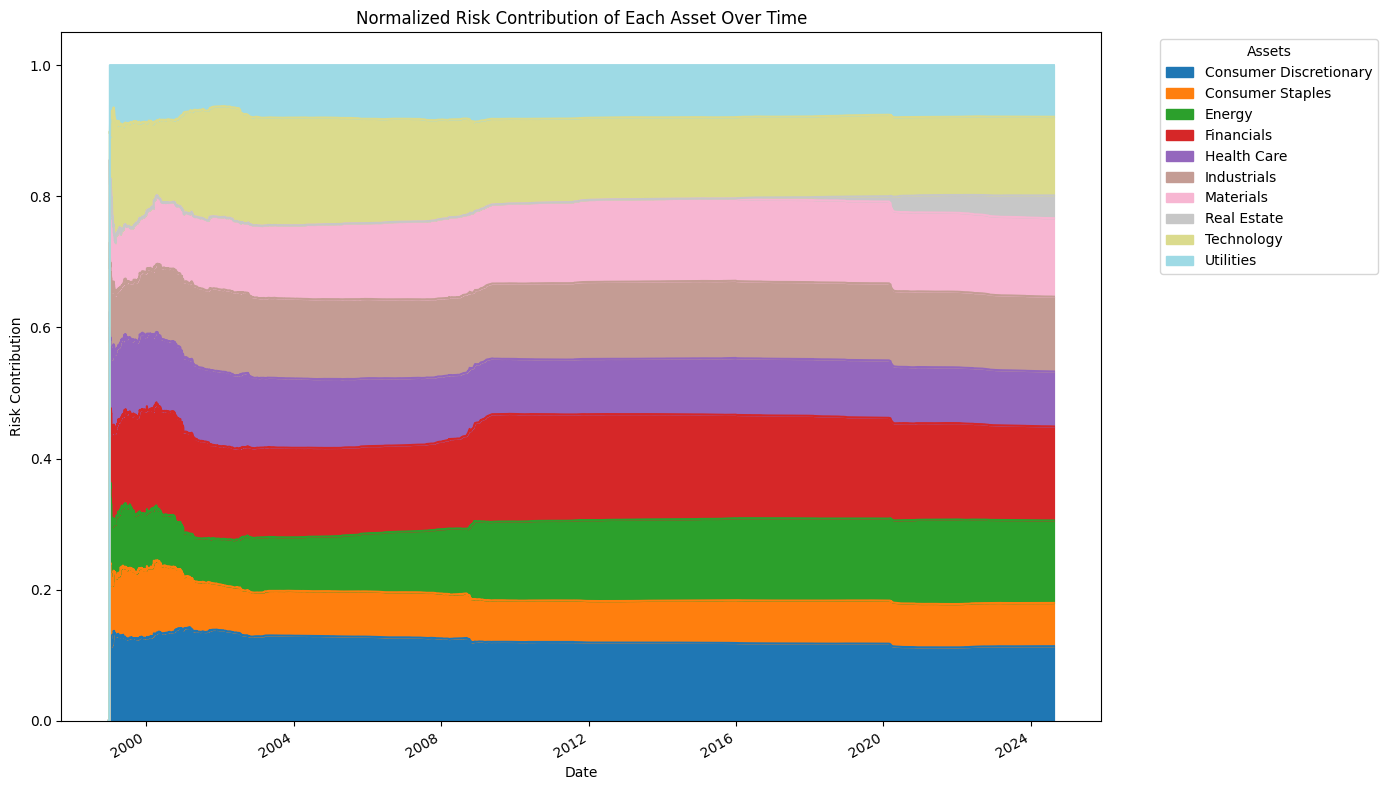

In [8]:
monthly_returns_df = (1 + returns_df).resample('ME').prod() - 1
# portfolio_returns = portfolio_allocation(returns_df, frequency='daily', method='eqCont')
# portfolio_returns = portfolio_allocation(returns_df, frequency='daily', method='minVol')
portfolio_returns, weights = portfolio_allocation(returns_df, frequency='daily', method='eqCont',
                                                               max_exposure=0.3)

# Plot the risk contribution
plot_portfolio_risk_contribution_history(weights_df=weights, returns_df=returns_df)

In [71]:
weights_parity = portfolio_optimization(returns=returns_df, frequency='daily', goal='riskParity')
weights_parity

Financials                0.064474
Technology                0.076686
Energy                    0.075947
Industrials               0.076298
Utilities                 0.104693
Consumer Staples          0.140272
Consumer Discretionary    0.076377
Health Care               0.102247
Materials                 0.076152
Real Estate               0.206854
dtype: float64

In [54]:
weights_parity.sum()

np.float64(1.0)

Can adapt our portfolio optimization to have each asset contribute equally to portfolio overall risk

In [72]:
cov_matrix = returns_df.cov() * 252

marginal_contributions = calculate_risk_contribution(w=weights_parity, V=cov_matrix)
marginal_contributions

Financials                0.015228
Technology                0.015377
Energy                    0.015834
Industrials               0.014595
Utilities                 0.014785
Consumer Staples          0.016568
Consumer Discretionary    0.014621
Health Care               0.014773
Materials                 0.015212
Real Estate               0.014542
dtype: float64

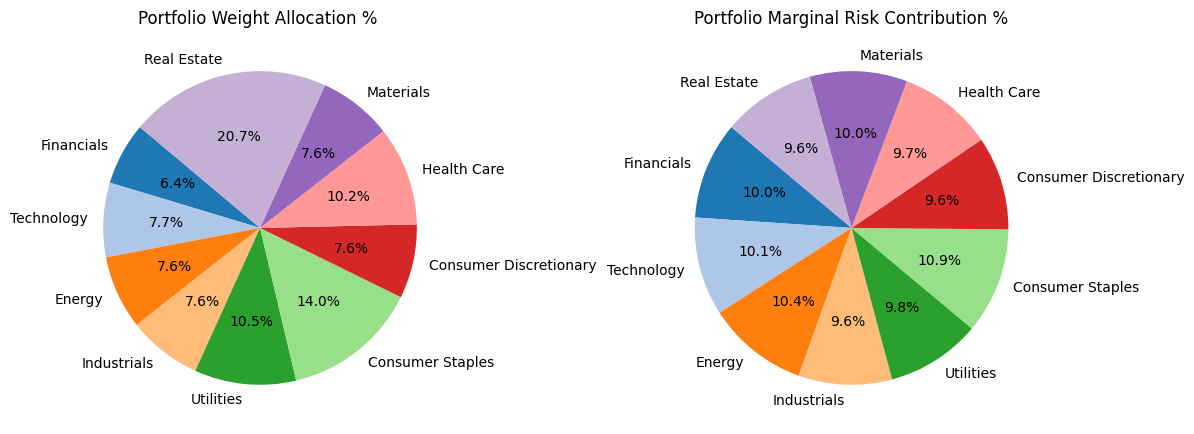

In [73]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# plot weight parity pie chart
ax[0].pie(weights_parity.values, labels=weights_parity.keys(), autopct='%1.1f%%', startangle=140, colors=plt.get_cmap('tab20').colors)
ax[0].set_title('Portfolio Weight Allocation % ')

# plot marginal contributions pie chart
ax[1].pie(marginal_contributions.values, labels=marginal_contributions.keys(), autopct='%1.1f%%', startangle=140, colors=plt.get_cmap('tab20').colors)
ax[1].set_title('Portfolio Marginal Risk Contribution %')

plt.tight_layout()
plt.show()

In [75]:
portfolio_returns, weights = portfolio_allocation(returns_df, frequency='daily', method='riskParity')
post_processing = portfolio_performance(portfolio_returns=portfolio_returns, frequency="daily")
post_processing

/home/alan/Quantropy/src/portfolio_optimization.py:257: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f"Error in optimization for date {date}: {e}")


{'cumulative_returns': Date
 1998-12-23    0.000000
 1998-12-24    0.000000
 1998-12-28    0.000000
 1998-12-29    0.000000
 1998-12-30    0.000000
                 ...   
 2024-08-12    7.265490
 2024-08-13    7.346361
 2024-08-14    7.373726
 2024-08-15    7.467049
 2024-08-16    7.462729
 Length: 6453, dtype: float64,
 'annualized_return': np.float64(0.103619512360825),
 'annualized_volatility': np.float64(0.1741715004897211),
 'sharpe_ratio': np.float64(0.5375133824856154),
 'portfolio_returns': Date
 1998-12-23    0.000000
 1998-12-24    0.000000
 1998-12-28    0.000000
 1998-12-29    0.000000
 1998-12-30    0.000000
                 ...   
 2024-08-12   -0.002099
 2024-08-13    0.009784
 2024-08-14    0.003279
 2024-08-15    0.011145
 2024-08-16   -0.000510
 Length: 6453, dtype: float64}

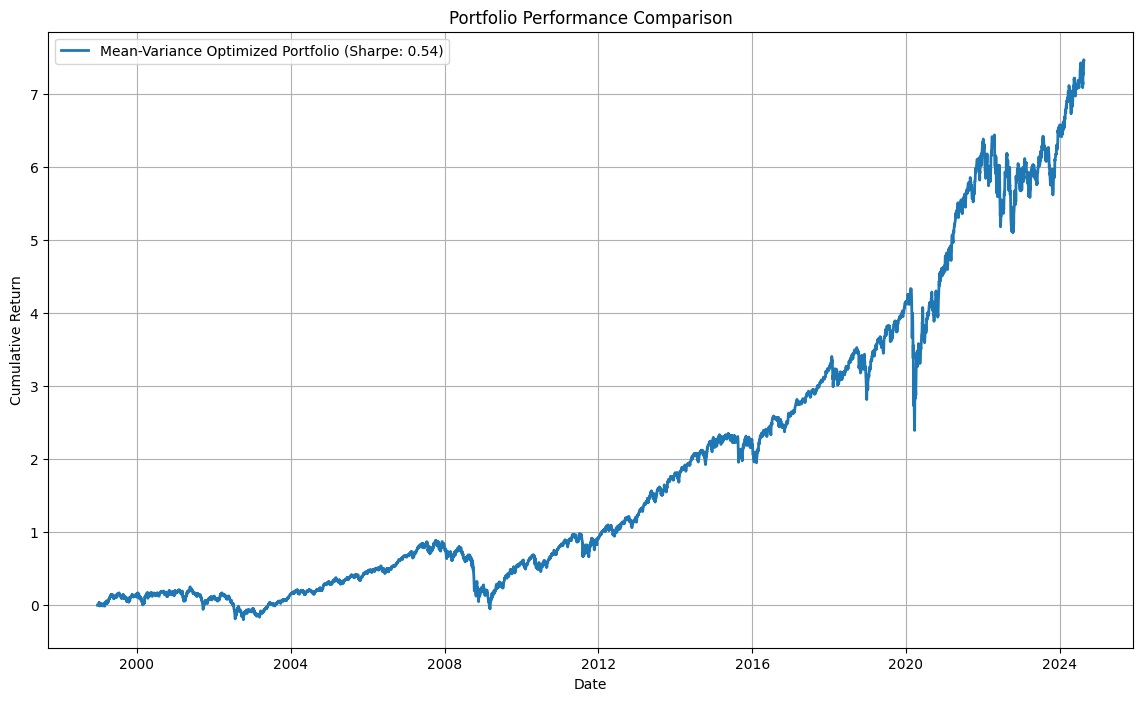

In [76]:
# Plot the performance
plot_portfolio_performance(portfolio_cum=post_processing["cumulative_returns"], sharpe=post_processing["sharpe_ratio"])

/home/alan/Quantropy/env/lib/python3.10/site-packages/pandas/core/frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/home/alan/Quantropy/env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/alan/Quantropy/env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/alan/Quantropy/src/portfolio_optimization.py:89: RuntimeWarning: invalid value encountered in divide
  return marginal_risk_contrib / portfolio_volatility


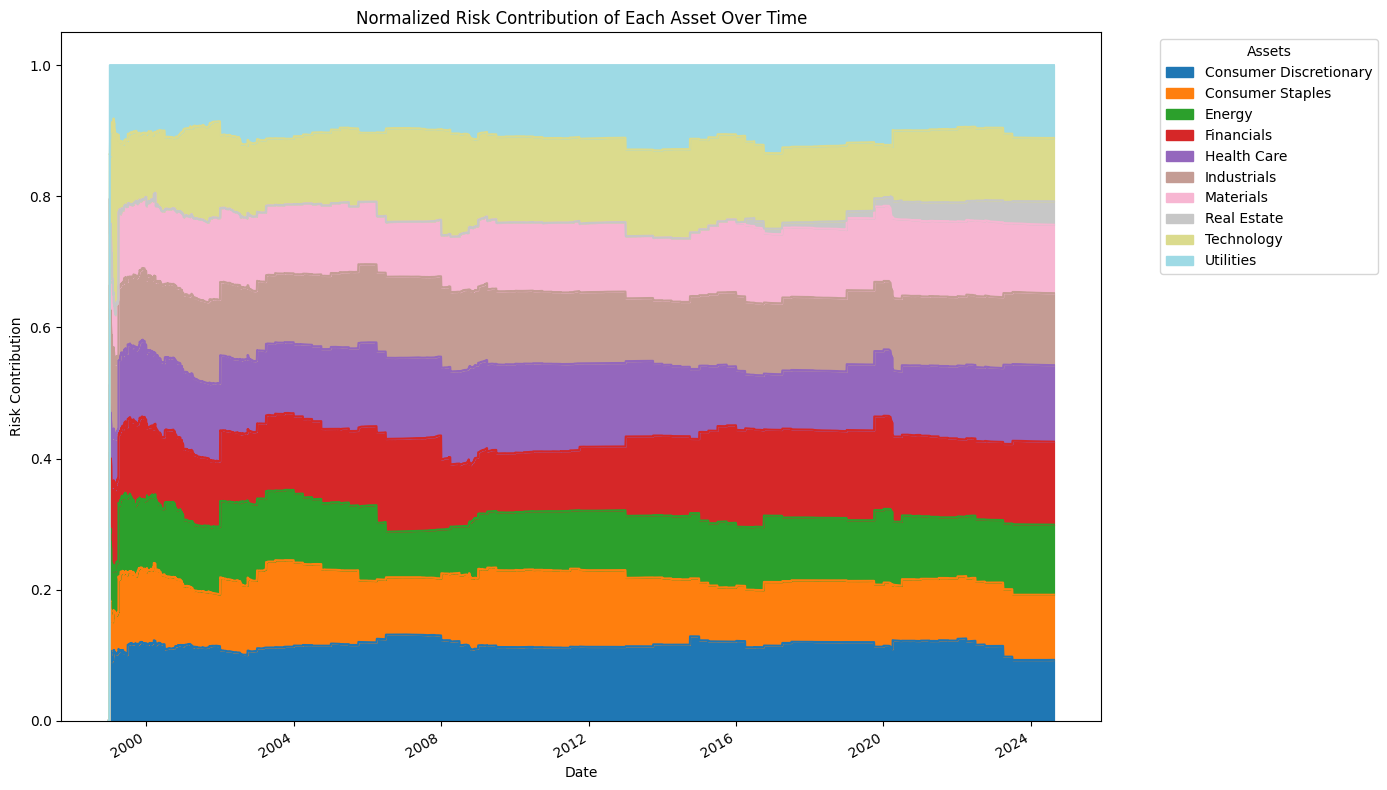

In [77]:
# Plot the risk contribution
plot_portfolio_risk_contribution_history(weights_df=weights, returns_df=returns_df)